# Exam Project

Import and set magics:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# 1 Real GDP across US states

In [ ]:
# user written modules
import Problem1

## 1.1 Question 1

### 1.1.1

In [ ]:
# US data from FRED

# 1. Connect to FRED
with open('fredapi.txt', 'r') as f:
    fred_api_key = f.read().strip()

from fredapi import Fred

fred = Fred(api_key=fred_api_key)

In [ ]:
# 2. Import state codes

from states import STATES

In [ ]:
# 3. Download real GDP and population for all states

gdp_data = {}
pop_data = {}

for state in STATES:
    gdp_data[state] = fred.get_series(state + 'RGSP')
    pop_data[state] = fred.get_series(state + 'POP')

# Convert dictionaries to data frames
gdp = pd.DataFrame(gdp_data)
pop = pd.DataFrame(pop_data)

# Change index to year and rename it to 'year'
gdp.index = gdp.index.year
gdp = gdp.rename_axis('year')

pop.index = pop.index.year
pop = pop.rename_axis('year')

# Show data frames
display(gdp.head())
display(pop.head())

,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1997,154700.0,41071.0,180293.9,87180.3,1441226.4,189445.6,205965.2,51267.0,603988.6,351183.9,...,27116.2,226832.8,860046.9,86283.5,21372.2,319992.6,281522.2,60364.6,222978.5,24257.7
1998,160396.4,40263.7,197492.1,89905.3,1538612.3,206449.1,212255.0,56487.0,634032.3,377705.9,...,28772.1,240963.4,920059.6,91312.7,22266.5,338931.5,299817.0,61725.7,232087.1,24804.7
1999,166531.8,39783.1,214293.9,94756.9,1655438.5,221040.8,218860.0,60866.2,664152.0,404465.2,...,30038.3,248457.5,957247.2,95206.8,23561.7,356391.8,322721.6,63691.7,242026.0,25866.8
2000,168695.3,38428.1,224729.3,95509.8,1784320.6,238739.3,233874.2,63388.8,693837.3,417713.5,...,32124.9,251030.2,989904.9,98648.5,24844.6,372914.1,325857.6,63364.6,248572.0,26614.2
2001,168448.3,40014.4,230885.6,95528.7,1784567.7,242650.1,236338.1,65724.8,714638.0,422731.6,...,32396.9,250311.4,1020517.0,100244.3,25681.8,386444.7,317860.6,63599.8,252941.8,28338.1


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1900,1830.0,NaN,124.0,1314.0,1490.0,543.0,910.0,185.0,530.0,2220.0,...,403.0,2023.0,3055.0,277.0,344.0,1858.0,523.0,959.0,2072.0,93.0
1901,1907.0,NaN,131.0,1341.0,1550.0,581.0,931.0,187.0,544.0,2263.0,...,418.0,2041.0,3132.0,284.0,347.0,1887.0,583.0,972.0,2109.0,100.0
1902,1935.0,NaN,138.0,1360.0,1623.0,621.0,952.0,188.0,565.0,2305.0,...,431.0,2060.0,3210.0,292.0,349.0,1894.0,651.0,1000.0,2141.0,105.0
1903,1957.0,NaN,144.0,1384.0,1702.0,652.0,972.0,190.0,587.0,2346.0,...,437.0,2082.0,3291.0,299.0,350.0,1890.0,719.0,1037.0,2171.0,108.0
1904,1978.0,NaN,151.0,1419.0,1792.0,659.0,987.0,192.0,599.0,2387.0,...,452.0,2086.0,3374.0,308.0,353.0,1889.0,782.0,1064.0,2202.0,111.0


### 1.1.2

In [ ]:
# 4. Keep common years and drop states with missing observations

# Find years available in both data frames
common_years = gdp.index.intersection(pop.index)

# Keep only the common years
gdp_common = gdp.loc[common_years]
pop_common = pop.loc[common_years]

# Find states with no missing observations in either data frame
valid_states = (
    gdp_common.columns[gdp_common.notna().all()]
    .intersection(pop_common.columns[pop_common.notna().all()])
)

# Keep only states with complete observations
gdp_common = gdp_common[valid_states]
pop_common = pop_common[valid_states]


In [ ]:
# Count remaining years and states
n_years = len(common_years)
n_states = len(valid_states)

# Identify first and last common year
t_first = common_years.min()
t_last = common_years.max()

# Show results
print(f"Number of years: {n_years}")
print(f"Number of states: {n_states}")
print(f"First year: {t_first}")
print(f"Last year: {t_last}")

Number of years: 29
Number of states: 50
First year: 1997
Last year: 2025


Conclusion: After restricting the data to the common time period and dropping states with missing observations, the final sample contains 50 states and 29 years, covering 1997–2025.

### 1.1.3

In [ ]:
# 5. Compute real GDP per person in dollars

y = (gdp_common / pop_common) * 1000

In [ ]:
# Show real GDP per person
display(y.head())

,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1997,35807.856017,67457.123805,39605.821967,34540.435110,44733.982939,48684.486108,63014.935839,69748.742898,41134.250699,46911.500176,...,37102.024341,42174.514399,44434.405916,41775.745777,36306.218308,47526.867411,50234.997381,33247.961542,42878.542989,50533.611371
1998,36863.947606,65447.615023,42314.201621,35420.860909,47077.134837,52015.826788,64858.950003,75916.652555,42529.012498,49460.461189,...,39371.282272,44354.433604,46674.180385,43470.604533,37702.830612,49921.971948,52711.999932,34070.822349,44443.046546,51671.614120
1999,38109.166834,64218.079096,44847.009375,37139.571517,49945.163875,54495.451702,66684.318338,80773.895942,43950.848785,51932.811521,...,40972.511127,45309.731770,47756.958006,44701.469972,39683.531512,51854.555973,56063.474824,35248.609795,46096.274488,53933.886848
2000,37890.553669,61194.847467,43547.244441,35656.771403,52498.582072,55175.331373,68549.087470,80609.074828,43236.432557,50771.619813,...,42502.024227,44011.670280,47263.240816,43951.174915,40754.374051,52480.115939,55131.873516,35065.779534,46254.567595,53842.201092
2001,37704.140491,63142.679505,43782.422868,35491.800142,51757.417416,54827.668563,68846.332550,82600.078673,43690.131776,50463.135060,...,42741.552458,43526.444806,47867.499715,43895.275899,41948.440356,53685.088358,53103.134426,35304.174732,46781.860367,57288.383668


Real GDP per person is computed as real GDP divided by population, multiplied by 1,000 to account for the difference between millions of dollars and thousands of persons.

### 1.1.4

In [ ]:
# 6. Compare real GDP per person in the first and last year

# Select real GDP per person in first and last year
y_first = y.loc[t_first]
y_last = y.loc[t_last]

In [ ]:
# Find highest and lowest values and corresponding states
highest_first = y_first.max()
lowest_first = y_first.min()
highest_state_first = y_first.idxmax()
lowest_state_first = y_first.idxmin()

highest_last = y_last.max()
lowest_last = y_last.min()
highest_state_last = y_last.idxmax()
lowest_state_last = y_last.idxmin()

In [ ]:
# Compute highest-to-lowest ratio and average across states
ratio_first = highest_first / lowest_first
ratio_last = highest_last / lowest_last

average_first = y_first.mean()
average_last = y_last.mean()

In [ ]:
# Show results
print(f"{t_first}:")
print(f"Highest: {highest_state_first}, ${highest_first:,.2f}")
print(f"Lowest: {lowest_state_first}, ${lowest_first:,.2f}")
print(f"Highest/lowest ratio: {ratio_first:.2f}")
print(f"Average: ${average_first:,.2f}")

print()

print(f"{t_last}:")
print(f"Highest: {highest_state_last}, ${highest_last:,.2f}")
print(f"Lowest: {lowest_state_last}, ${lowest_last:,.2f}")
print(f"Highest/lowest ratio: {ratio_last:.2f}")
print(f"Average: ${average_last:,.2f}")

1997:
Highest: DE, $69,748.74
Lowest: ID, $32,062.68
Highest/lowest ratio: 2.18
Average: $44,592.95

2025:
Highest: NY, $94,701.99
Lowest: MS, $42,434.03
Highest/lowest ratio: 2.23
Average: $64,674.46


Conclusion: In 1997, Delaware had the highest real GDP per person ($69,748.74), while Idaho had the lowest ($32,062.68), giving a highest-to-lowest ratio of 2.18. In 2025, New York had the highest ($94,701.99) and Mississippi the lowest ($42,434.03), with a ratio of 2.23. The average real GDP per person increased from $44,592.95 in 1997 to $64,674.46 in 2025. The slightly higher ratio in 2025 indicates that the gap between the highest- and lowest-GDP-per-person states increased slightly over the period.

### 1.1.5

In [ ]:
# 7. Prepare data for figures

# Select a handful of states
selected_states = ['CA', 'NY', 'TX', 'MS', 'ID']

# Compute average real GDP per person across states for each year
y_average = y.mean(axis=1)

# Compute GDP per person relative to the average in each year
y_relative = y.div(y_average, axis=0)

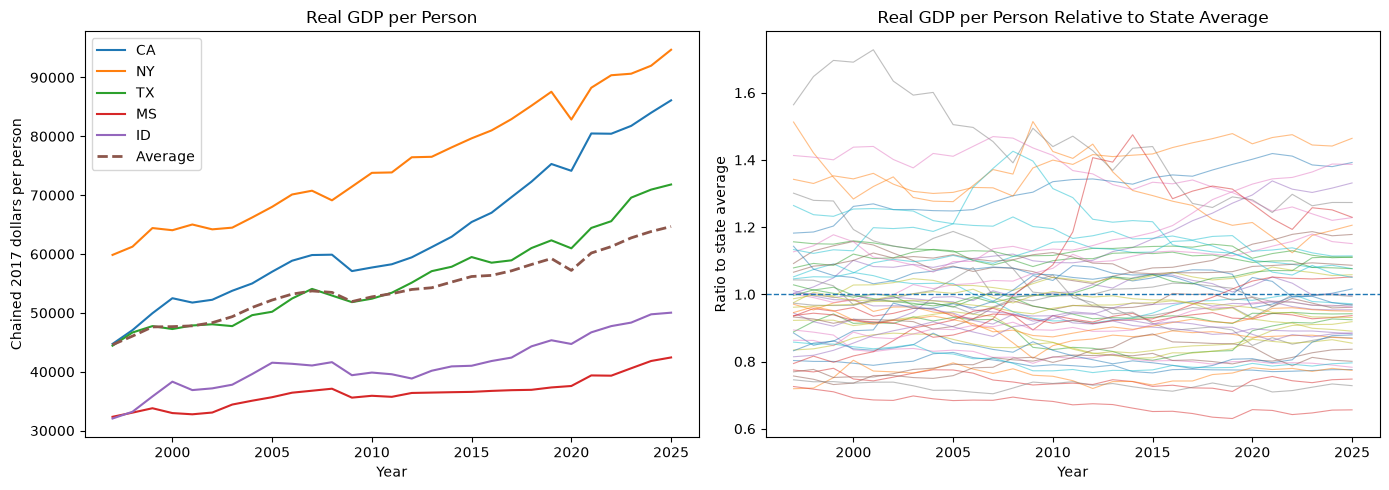

In [ ]:
# 8. Plot real GDP per person and relative GDP per person

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel i: Real GDP per person for selected states and state average
for state in selected_states:
    axes[0].plot(y.index, y[state], label=state)

axes[0].plot(y.index, y_average, label='Average', 
             linestyle='--', linewidth=2)

axes[0].set_title('Real GDP per Person')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Chained 2017 dollars per person')
axes[0].legend()

# Panel ii: Real GDP per person relative to state average
for state in y.columns:
    axes[1].plot(y_relative.index, y_relative[state], 
                 alpha=0.5, linewidth=0.8)

axes[1].axhline(1, linestyle='--', linewidth=1)
axes[1].set_title('Real GDP per Person Relative to State Average')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Ratio to state average')

plt.tight_layout()
plt.show()

Conclusion: The left panel shows the development in real GDP per person for the selected states and the average across all states. New York and California are above the state average in recent years, while Mississippi and Idaho remain below it. The right panel expresses each state's GDP per person relative to the average across all 50 states in the same year, where a value above (below) 1 indicates that the state is above (below) the state average. The right panel shows persistent cross-state differences relative to the annual average, although the relative positions of some states change over time.

## 1.2 Question 2

### 1.2.1

In [ ]:
# 9. Compute the standard deviation of log GDP per person across states

log_y = np.log(y)

std_log_y = log_y.std(axis=1)

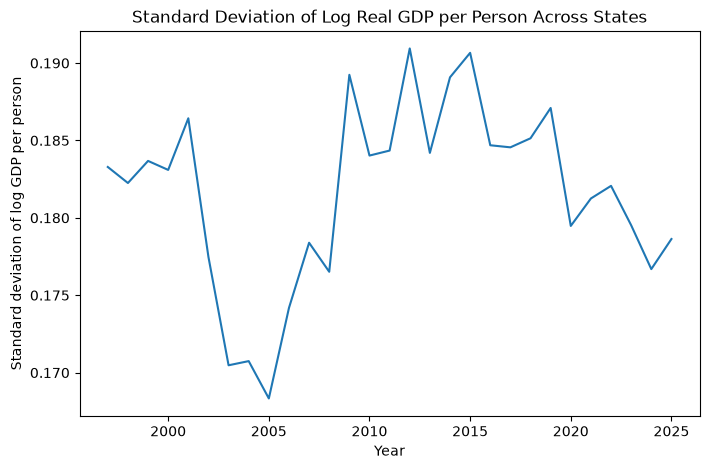

In [ ]:
# Plot the standard deviation over time

plt.figure(figsize=(8, 5))
plt.plot(std_log_y.index, std_log_y)

plt.title('Standard Deviation of Log Real GDP per Person Across States')
plt.xlabel('Year')
plt.ylabel('Standard deviation of log GDP per person')

plt.show()

The standard deviation shows how much log real GDP per person differs across states in each year. A higher standard deviation means larger differences between states, while a lower standard deviation means that states are more similar.

### 1.2.2

In [ ]:
# 10. Report standard deviation in first and last year

std_first = std_log_y.loc[t_first]
std_last = std_log_y.loc[t_last]

# Find highest and lowest standard deviation
highest_std = std_log_y.max()
highest_std_year = std_log_y.idxmax()

lowest_std = std_log_y.min()
lowest_std_year = std_log_y.idxmin()

# Show results
print(f"Standard deviation in {t_first}: {std_first:.4f}")
print(f"Standard deviation in {t_last}: {std_last:.4f}")
print(f"Highest standard deviation: {highest_std:.4f} in {highest_std_year}")
print(f"Lowest standard deviation: {lowest_std:.4f} in {lowest_std_year}")

Standard deviation in 1997: 0.1833
Standard deviation in 2025: 0.1786
Highest standard deviation: 0.1909 in 2012
Lowest standard deviation: 0.1683 in 2005


Conclusion: The standard deviation of log real GDP per person was 0.1833 in 1997 and 0.1786 in 2025. It reached its highest value of 0.1909 in 2012 and its lowest value of 0.1683 in 2005.

### 1.2.3

Conclusion: The standard deviation fluctuates considerably over the period. It falls until around 2005, indicating convergence across states, but subsequently rises and reaches its highest level in 2012, indicating divergence. These fluctuations may partly reflect that economic shocks, such as the 2008–09 financial crisis, affected states differently due to differences in their economic structure. After 2012, the standard deviation generally declines again. Overall, the standard deviation decreases only slightly from 0.1833 in 1997 to 0.1786 in 2025 and while there is some convergence from the first to the last year, we cannot identify a clear convergence trend over the full period, as the standard deviation fluctuates considerably over time.

## 1.3 Question 3

### 1.3.1

In [ ]:
# 11. Compute average annual growth rate for each state

T = t_last - t_first

log_y_first = np.log(y.loc[t_first])
log_y_last = np.log(y.loc[t_last])

g = (log_y_last - log_y_first) / T

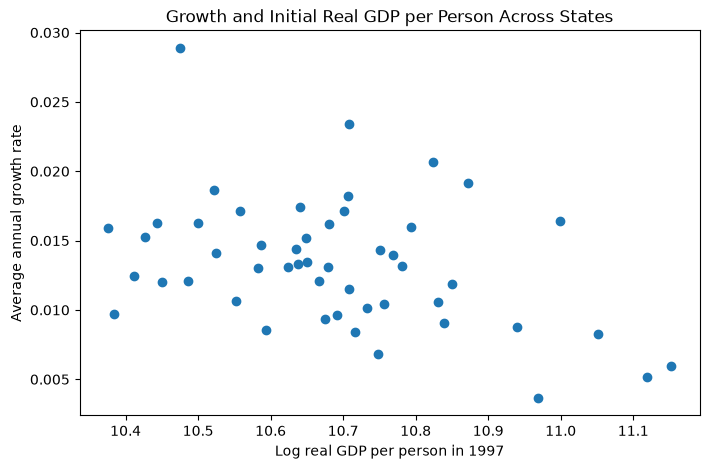

In [ ]:
# Plot average annual growth against initial log GDP per person

plt.figure(figsize=(8, 5))

plt.scatter(log_y_first, g)

plt.xlabel('Log real GDP per person in 1997')
plt.ylabel('Average annual growth rate')
plt.title('Growth and Initial Real GDP per Person Across States')

plt.show()

### 1.3.2

In [ ]:
# 12. Fit a straight line through the points

b, a = np.polyfit(log_y_first, g, 1)

# Compute correlation
correlation = log_y_first.corr(g)

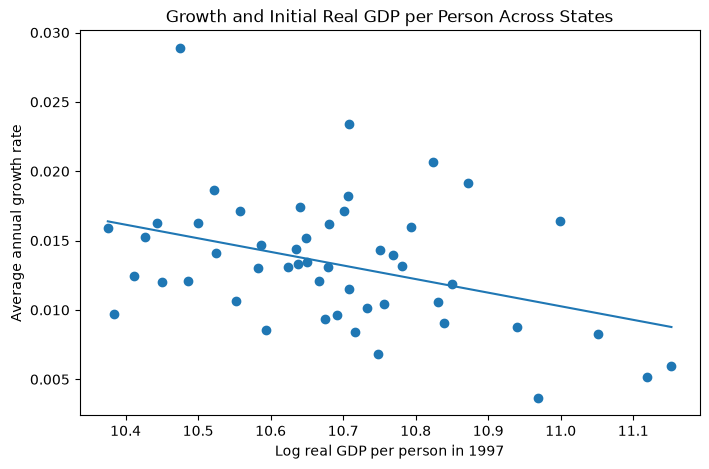

In [ ]:
# Plot scatter points and fitted line

plt.figure(figsize=(8, 5))

plt.scatter(log_y_first, g)

x_line = np.linspace(log_y_first.min(), log_y_first.max(), 100)
plt.plot(x_line, a + b * x_line)

plt.xlabel('Log real GDP per person in 1997')
plt.ylabel('Average annual growth rate')
plt.title('Growth and Initial Real GDP per Person Across States')

plt.show()

In [ ]:
# Show regression results

print(f"Intercept (a): {a:.4f}")
print(f"Slope (b): {b:.4f}")
print(f"Correlation: {correlation:.4f}")

Intercept (a): 0.1181
Slope (b): -0.0098
Correlation: -0.3886


Conclusion: The estimated slope is \(b=-0.0098\), and the correlation between initial log real GDP per person and subsequent growth is \(-0.3886\). The negative relationship indicates beta convergence: states with lower initial GDP per person tended to grow faster over the period. However, the considerable dispersion around the fitted line suggests that the relationship is not particularly strong.

### 1.3.3

In [ ]:
# 13. Identify states with highest and lowest growth rates

highest_growth = g.nlargest(5)
lowest_growth = g.nsmallest(5)

# Show states
print("Five states with highest growth:")
for state, growth in highest_growth.items():
    print(f"{state}: {growth:.4f}")

print("\nFive states with lowest growth:")
for state, growth in lowest_growth.items():
    print(f"{state}: {growth:.4f}")

Five states with highest growth:
ND: 0.0289
CA: 0.0234
WA: 0.0207
MA: 0.0191
SD: 0.0187

Five states with lowest growth:
NV: 0.0037
AK: 0.0052
DE: 0.0059
LA: 0.0068
CT: 0.0083


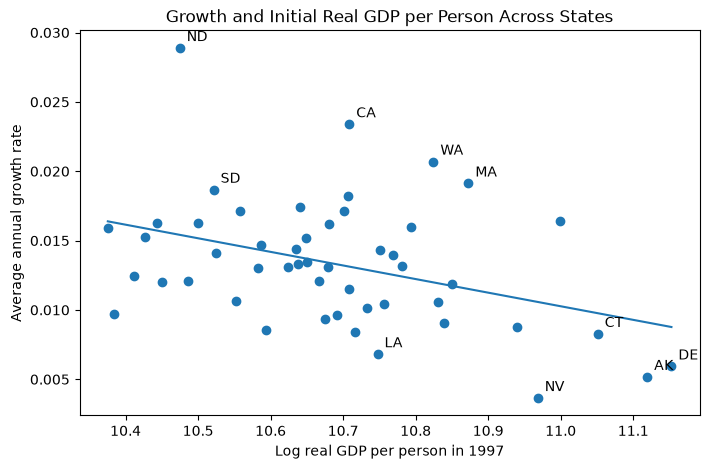

In [ ]:
# Plot scatter points, fitted line, and labels

plt.figure(figsize=(8, 5))

plt.scatter(log_y_first, g)

x_line = np.linspace(log_y_first.min(), log_y_first.max(), 100)
plt.plot(x_line, a + b * x_line)

# Add labels for states with highest and lowest growth rates
states_to_label = highest_growth.index.union(lowest_growth.index)

for state in states_to_label:
    plt.annotate(
        state,
        (log_y_first[state], g[state]),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Log real GDP per person in 1997')
plt.ylabel('Average annual growth rate')
plt.title('Growth and Initial Real GDP per Person Across States')

plt.show()

Conclusion: The states with the highest average growth rates are North Dakota, California, Washington, Massachusetts and South Dakota, while Nevada, Alaska, Delaware, Louisiana and Connecticut have the lowest growth rates. The labeled points also illustrate that growth outcomes vary substantially across states, even for states with similar initial GDP per person.

### 1.3.4

In [ ]:
# 14. Compute speed of convergence and half-life

T = t_last - t_first

lambda_conv = -np.log(1 + b * T) / T
half_life = np.log(2) / lambda_conv

# Show results
print(f"Speed of convergence (lambda): {lambda_conv:.4f}")
print(f"Half-life (h): {half_life:.2f} years")

Speed of convergence (lambda): 0.0115
Half-life (h): 60.49 years


Conclusion: The estimated annual speed of convergence is 1.15%, meaning that approximately 1.15% of the effect of the initial gap in real GDP per person disappears each year. The corresponding half-life is approximately 60.5 years, meaning that it takes about 60 years for half of an initial gap between states to disappear. This implies that differences in initial real GDP per person disappear relatively slowly over time.

### 1.3.5

Conclusion: The fitted line slopes downward, indicating beta convergence. States with lower initial real GDP per person tended to experience higher subsequent growth. However, the points are relatively dispersed around the fitted line, which is consistent with the moderate negative correlation of -0.3886. The estimated convergence speed of 1.15% per year further suggests that convergence is relatively slow, as only a small part of the initial gap disappears each year. This is also reflected in the estimated half-life of approximately 60.5 years. Thus, while the figure provides evidence of beta convergence, the relationship is not particularly strong and differences in GDP per person across states disappear only gradually over time. Therefore, initial GDP per person is related to subsequent growth, but it does not explain all of the differences in growth rates across states.

This is also consistent with the earlier results in the sense that beta convergence can be present even without a clear downward trend in the overall dispersion of GDP per person across states.

## 1.4 Question 4

### 1.4.1

In [ ]:
# 15. Import region information

from states import REGION

In [ ]:
# Count the number of states in each region

region_counts = (
    pd.Series(REGION)
    .value_counts()
    .rename_axis('Region')
    .reset_index(name='Number of states')
)

region_counts

,Region,Number of states
0,South,16
1,West,13
2,Midwest,12
3,Northeast,9


In [ ]:
# Create a region label for each state

state_regions = pd.Series(REGION).reindex(y.columns)

In [ ]:
# Compute average GDP per person within each region

region_average = y.T.groupby(state_regions).mean().T

region_average.head()

,Midwest,Northeast,South,West
year,,,,
1997,43180.798007,48487.699166,42422.062385,45871.955830
1998,44607.752165,50093.105063,44120.203220,46995.539623
1999,45854.585625,51982.553603,45665.857667,48643.607472
2000,46555.188229,52954.139771,44968.040556,48369.835431
2001,46339.288064,53521.899505,45348.431403,48227.726221


In [ ]:
# Compute average GDP per person across all states

overall_average = y.mean(axis=1)

display(overall_average.head().to_frame(name='Overall average'))

,Overall average
year,
1997,44592.945851
1998,46059.924764
1999,47622.372595
2000,47670.920524
2001,47806.077913


In [ ]:
# Compute regional GDP per person relative to the overall state average

region_relative = region_average.div(overall_average, axis=0)

region_relative.head()

,Midwest,Northeast,South,West
year,,,,
1997,0.968332,1.087340,0.951318,1.028682
1998,0.968472,1.087564,0.957887,1.020313
1999,0.962879,1.091557,0.958916,1.021444
2000,0.976595,1.110827,0.943301,1.014661
2001,0.969318,1.119563,0.948591,1.008820


Conclusion: The four regions contain 9 states in the Northeast, 12 in the Midwest, 16 in the South, and 13 in the West. For each year, regional average real GDP per person is divided by the average across all states. A value above 1 therefore indicates that a region has higher average real GDP per person than the overall state average, while a value below 1 indicates a lower average.

### 1.4.2

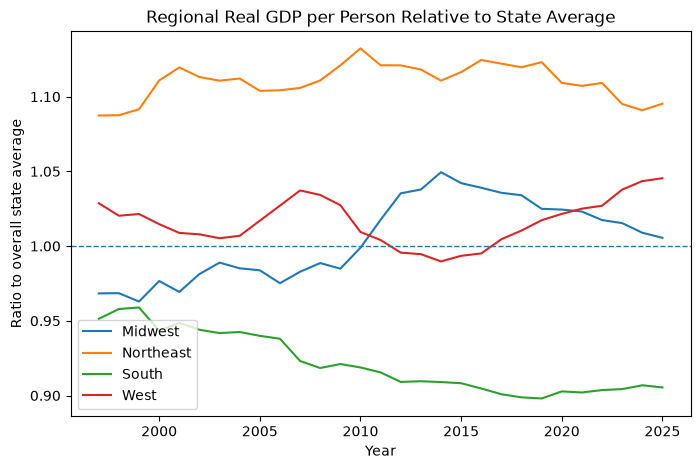

In [ ]:
# 16. Plot regional GDP per person relative to the overall average

plt.figure(figsize=(8, 5))

for region in region_relative.columns:
    plt.plot(region_relative.index, region_relative[region], label=region)

plt.axhline(1, linestyle='--', linewidth=1)

plt.xlabel('Year')
plt.ylabel('Ratio to overall state average')
plt.title('Regional Real GDP per Person Relative to State Average')
plt.legend()

plt.show()

Conclusion: The figure shows clear differences in relative real GDP per person across the four regions. The Northeast remains above the overall state average throughout the period, while the South remains below it. The Midwest moves from below to slightly above the overall average, while the West fluctuates around the overall average.

### 1.4.3

In [ ]:
# 17. Get regional values in the first and last year

first_values = region_relative.loc[t_first]
last_values = region_relative.loc[t_last]

In [ ]:
# Compute the change between the first and last year

change = last_values - first_values

In [ ]:
# Combine first year, last year, and change in one table

regional_changes = pd.DataFrame({
    'First year': first_values,
    'Last year': last_values,
    'Change': change
})

regional_changes

,First year,Last year,Change
Midwest,0.968332,1.005527,0.037194
Northeast,1.087340,1.095232,0.007892
South,0.951318,0.905418,-0.045900
West,1.028682,1.045378,0.016696


In [ ]:
# Identify the region with the largest absolute change

largest_move_region = change.abs().idxmax()
largest_move = change[largest_move_region]

print(f"Region with largest change: {largest_move_region}")
print(f"Change: {largest_move:.4f}")

Region with largest change: South
Change: -0.0459


Conclusion: Between the first and last year, the Midwest increases from 0.9683 to 1.0055, the Northeast from 1.0873 to 1.0952, and the West from 1.0287 to 1.0454. These positive changes indicate that the regions have increased their real GDP per person relative to the overall state average. In contrast, the South decreases from 0.9513 to 0.9054, indicating that its real GDP per person has fallen further relative to the overall state average. The South therefore experiences the largest absolute change, with a decrease of approximately 0.0459. 
Thus, the South moves the most over the period, and the movement is downward relative to the overall state average.

# Problem 2: The Solow model with a time-varying savings rate

All variables are per worker. Output is $y_t=k_t^\alpha$, a share $s_t$ of output is invested,
and capital accumulates as $k_{t+1}=s_tf(k_t)+(1-\delta)k_t$.

Welfare of a consumption path is $W=\sum_{t=0}^{T-1}\beta^t\log c_t$.

The starting point is `SolowModel.py`, which is left exactly as it was handed out. The three
methods that raise `NotImplementedError` there are implemented below in a subclass,
`SolowModelExam`, so everything written for this exam is collected in one place and the original
file is untouched.

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

from SolowModel import SolowModelClass

plt.rcParams.update({'font.size':11,'figure.dpi':100,'axes.grid':True,'grid.alpha':0.3})

print('SolowModel.py imported')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
SolowModel.py imported


## The missing methods

`s_path`, `welfare` and `evaluate` are inherited from `SolowModelClass` but raise
`NotImplementedError`. They are overwritten here in a subclass, together with one extra helper,
`evaluate_path`, used for the alternative rules in Question 6.

`s_path` is written with an optional third argument `s_inf`. Leaving it out gives equation (6),
$s_t=\bar{s}+(s_0-\bar{s})\varphi^t$, which is what Questions 2-4 need, while passing it gives
the three-parameter rule of Question 5. That way the same method covers both.

In [3]:
class SolowModelExam(SolowModelClass):
    """ the Solow model of Lecture 9, with the methods needed for the exam """

    def s_path(self,s0,phi,s_inf=None):
        """ the savings path s_t = s_inf + (s0-s_inf)*phi**t

        Args:

            s0 (float): savings rate in period 0
            phi (float): speed of return to the long-run level, in [0,1)
            s_inf (float,optional): long-run savings rate, par.s_bar is used if None,
                which gives equation (6)

        Returns:

            (ndarray): the savings rate in each of the par.T periods

        """

        par = self.par
        if s_inf is None: s_inf = par.s_bar

        t = np.arange(par.T)
        s = s_inf + (s0-s_inf)*phi**t

        # note: numpy sets 0**0 = 1, so phi = 0 correctly gives s_0 = s0 and s_t = s_inf after that
        return np.clip(s,0.0,1.0) # the savings rate must stay in [0,1]

    def welfare(self,c):
        """ the discounted sum of log(c_t), W = sum_t beta**t*log(c_t)

        Args:

            c (ndarray): the consumption path

        Returns:

            (float): welfare W, -np.inf if consumption is non-positive in some period

        """

        par = self.par

        # a. log(c) is only defined for c > 0, a path with c = 0 is infinitely bad
        if np.any(c <= 0): return -np.inf

        # b. the discounted sum
        beta_vec = par.beta**np.arange(c.size)

        return np.sum(beta_vec*np.log(c))

    def evaluate(self,s0,phi,s_inf=None):
        """ welfare of the savings rule (s0,phi,s_inf) """

        s_vec = self.s_path(s0,phi,s_inf)
        sim = self.simulate(s_vec)

        return self.welfare(sim.c)

    def evaluate_path(self,s_vec):
        """ welfare of an arbitrary savings path, used for the rules in Question 6 """

        sim = self.simulate(s_vec)

        return self.welfare(sim.c)

model = SolowModelExam()
par = model.par
print(model)

Solow model with:
  alpha = 0.3333 (capital share)
  delta = 0.3000 (depreciation rate)
  s_bar = 0.2500 (long-run savings rate)
  beta  = 0.8333 (discount factor)
  k0    = 0.1000 (initial capital per worker)
  T     = 100 (number of periods)


In [4]:
def store(sim):
    """ copy the simulated paths out of the model, so they are not overwritten
        by the next call to simulate """

    return dict(s=sim.s.copy(),k=sim.k.copy(),c=sim.c.copy(),y=sim.y.copy())

def plot_paths(paths,figsize=(14,4)):
    """ plot s_t, k_t and c_t against t in three panels

    Args:

        paths (dict): {label: dict of paths from store()}

    """

    fig,axes = plt.subplots(1,3,figsize=figsize)
    t = np.arange(par.T)

    for name,var,title in zip(['s','k','c'],axes,
        ['savings rate, $s_t$','capital, $k_t$','consumption, $c_t$']):

        for label,path in paths.items():
            ls = '--' if label == 'baseline' else '-'
            lw = 2.5 if label == 'baseline' else 1.5
            var.plot(t,path[name],ls,lw=lw,label=label,color='black' if label=='baseline' else None)

        var.set_title(title)
        var.set_xlabel('$t$')

    axes[0].legend(frameon=True,fontsize=9)
    fig.tight_layout()

    return fig,axes

### Question 1

### 1. Steady state for $s=\bar{s}$

In [5]:
# a. analytical steady state
k_ss,y_ss,c_ss = model.steady_state() # s = par.s_bar by default

# b. numerical steady state, the root of k_next(k,s)-k
k_ss_num = model.solve_steady_state()

print(f'analytical: k* = {k_ss:.6f}, y* = {y_ss:.6f}, c* = {c_ss:.6f}')
print(f'root-finder: k* = {k_ss_num:.6f}')
print(f'difference: {np.abs(k_ss-k_ss_num):.2e}')

assert np.isclose(k_ss,k_ss_num), 'the analytical and the numerical steady state disagree'

analytical: k* = 0.760726, y* = 0.912871, c* = 0.684653
root-finder: k* = 0.760726
difference: 0.00e+00


The two agree to machine precision, so the formula and the law of motion are consistent.

### 2. The baseline simulation

In [6]:
baseline = store(model.simulate(par.s_bar))

print(f'c_0     = {baseline["c"][0]:.6f}')
print(f'c_(T-1) = {baseline["c"][-1]:.6f}   (c* = {c_ss:.6f})')
print(f'k_(T-1) = {baseline["k"][-1]:.6f}   (k* = {k_ss:.6f})')

c_0     = 0.348119
c_(T-1) = 0.684653   (c* = 0.684653)
k_(T-1) = 0.760726   (k* = 0.760726)


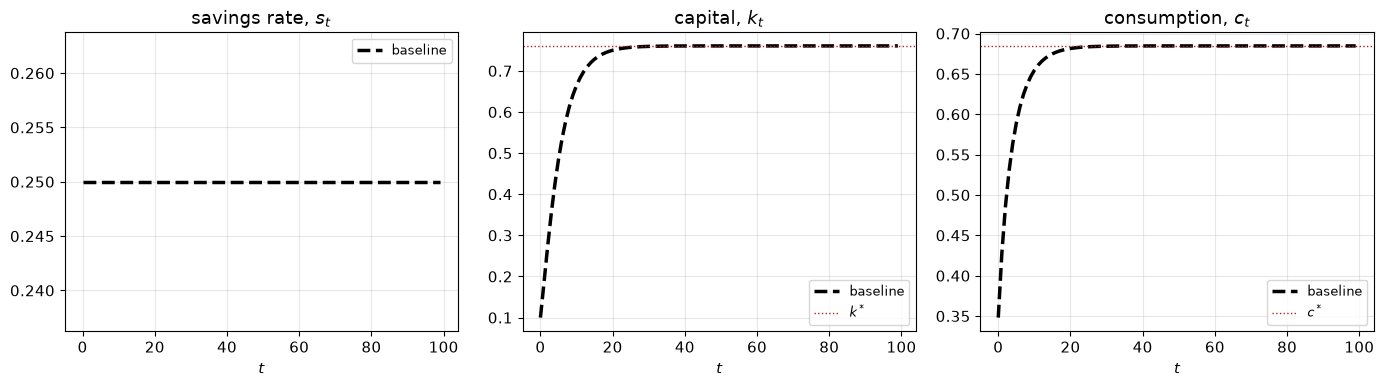

In [7]:
fig,axes = plot_paths({'baseline':baseline})
axes[1].axhline(k_ss,color='firebrick',lw=1,ls=':',label='$k^*$')
axes[2].axhline(c_ss,color='firebrick',lw=1,ls=':',label='$c^*$')
axes[1].legend(fontsize=9); axes[2].legend(fontsize=9)
plt.show()

Starting from $k_0=0.10$, far below $k^*$, capital rises quickly and then flattens out.
By $t=T-1$ the economy has been in the steady state for a long time: $k_{T-1}=k^*$ and
$c_{T-1}=c^*$ to six decimals.

### 3. Testing the simulator

Three cases where the answer is known in advance:

1. an economy starting in $k^*$ with $s_t=\bar{s}$ must stay in $k^*$ forever
2. with $s_t=0$ nothing is invested, so capital decays as $k_t=(1-\delta)^tk_0$
3. with $s_t=0$ all output is consumed, so $c_t=y_t=k_t^\alpha$

In [8]:
# test 1: the steady state is a fixed point
sim = model.simulate(par.s_bar,k0=k_ss)
assert np.allclose(sim.k,k_ss), 'an economy starting in k* must stay in k*'

# test 2: with s = 0 capital decays geometrically
sim = model.simulate(0.0)
k_analytical = (1-par.delta)**np.arange(par.T)*par.k0
assert np.allclose(sim.k,k_analytical), 'with s = 0 capital must decay as (1-delta)^t*k0'

# test 3: with s = 0 everything is consumed
assert np.allclose(sim.c,sim.y), 'with s = 0 consumption must equal output'

print('all tests passed')

all tests passed


### Question 2

The savings rule is
$$s_t=\bar{s}+(s_0-\bar{s})\varphi^t$$
implemented in `s_path` above. It is evaluated for the four combinations below.

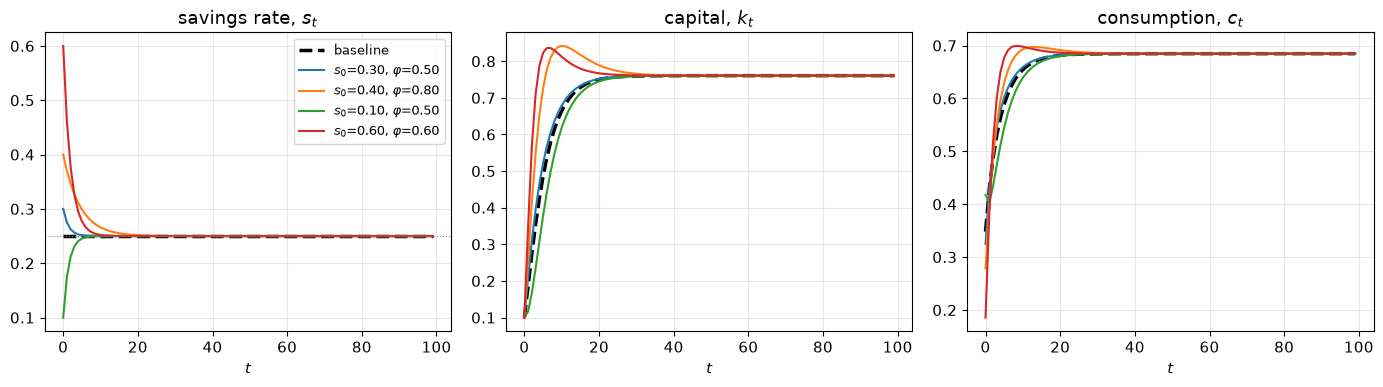

In [9]:
combos = [(0.30,0.50),(0.40,0.80),(0.10,0.50),(0.60,0.60)]

paths = {'baseline':baseline}
for s0,phi in combos:
    label = f'$s_0$={s0:.2f}, $\\varphi$={phi:.2f}'
    paths[label] = store(model.simulate(model.s_path(s0,phi)))

fig,axes = plot_paths(paths)
axes[0].axhline(par.s_bar,color='grey',lw=0.8,ls=':')
plt.show()

### 3. Capital in the last period

In [10]:
rows = [{'s0':np.nan,'phi':np.nan,'k_(T-1)':baseline['k'][-1],'s_(T-1)':baseline['s'][-1]}]
for s0,phi in combos:
    path = paths[f'$s_0$={s0:.2f}, $\\varphi$={phi:.2f}']
    rows.append({'s0':s0,'phi':phi,'k_(T-1)':path['k'][-1],'s_(T-1)':path['s'][-1]})

table = pd.DataFrame(rows,index=['baseline']+[f'({s0:.2f},{phi:.2f})' for s0,phi in combos])
display(table.style.format({'s0':'{:.2f}','phi':'{:.2f}','k_(T-1)':'{:.6f}','s_(T-1)':'{:.6f}'},na_rep='-'))

print(f'largest deviation from k* = {np.max([abs(r["k_(T-1)"]-k_ss) for r in rows]):.2e}')

,s0,phi,k_(T-1),s_(T-1)
baseline,-,-,0.760726,0.250000
"(0.30,0.50)",0.30,0.50,0.760726,0.250000
"(0.40,0.80)",0.40,0.80,0.760726,0.250000
"(0.10,0.50)",0.10,0.50,0.760726,0.250000
"(0.60,0.60)",0.60,0.60,0.760726,0.250000


largest deviation from k* = 4.07e-09


**Yes, they are all the same**, equal to $k^*=0.760726$.

Since $\varphi<1$, $\varphi^t\to0$ and $s_t\to\bar{s}$ whatever $s_0$ is. Capital then converges
to the steady state belonging to $\bar{s}$, and $T=100$ leaves plenty of time for that. $s_0$ and
$\varphi$ shape the *transition*, never the long-run level.

### 4. What $s_0$ and $\varphi$ do

**$s_0$ sets where the path starts.** A high $s_0$ (0.60) means little consumption early but fast
capital accumulation, so $c_t$ starts below the baseline and crosses it after a few periods. A
low $s_0$ (0.10) does the opposite.

**$\varphi$ sets how long the deviation lasts.** $\varphi^t$ is the share of the initial gap left
in period $t$, a half-life of $\log(0.5)/\log\varphi$: 1 period for $\varphi=0.50$, 3 for
$\varphi=0.80$. That is why $(0.40,0.80)$ stays below the baseline far longer than
$(0.30,0.50)$, despite a barely higher $s_0$.

The two interact: what matters for capital is the area under $s_t-\bar{s}$, equal to
$(s_0-\bar{s})/(1-\varphi)$.

### Question 3

Welfare is $W=\sum_{t=0}^{T-1}\beta^t\log c_t$, implemented in `welfare` above.

In [11]:
W_baseline = model.welfare(baseline['c'])

rows = [{'s0':np.nan,'phi':np.nan,'W':W_baseline,'W - W_baseline':0.0}]
for s0,phi in combos:
    W = model.evaluate(s0,phi)
    rows.append({'s0':s0,'phi':phi,'W':W,'W - W_baseline':W-W_baseline})

table = pd.DataFrame(rows,index=['baseline']+[f'({s0:.2f},{phi:.2f})' for s0,phi in combos])
display(table.style.format({'s0':'{:.2f}','phi':'{:.2f}','W':'{:.6f}','W - W_baseline':'{:+.6f}'},na_rep='-')
             .background_gradient(subset=['W'],cmap='RdYlGn'))

,s0,phi,W,W - W_baseline
baseline,-,-,-3.994388,+0.000000
"(0.30,0.50)",0.30,0.50,-3.985706,+0.008682
"(0.40,0.80)",0.40,0.80,-4.091413,-0.097025
"(0.10,0.50)",0.10,0.50,-4.146018,-0.151630
"(0.60,0.60)",0.60,0.60,-4.340653,-0.346265


### 3. Which combinations beat the baseline?

Only **$(s_0,\varphi)=(0.30,0.50)$**, by a small margin ($+0.0087$). The other three are worse,
$(0.60,0.60)$ by a lot ($-0.3463$).

**Could this have been seen from the figure alone? Not reliably.** The consumption paths cross
the baseline: every rule with $s_0>\bar{s}$ consumes less early and more later, and the figure
does not say how the two are weighted. $W$ does. With $\beta=1/1.2$ discounting is heavy
($\beta^{10}\approx0.16$, $\beta^{20}\approx0.03$), so the first 10-15 periods dominate the sum
while the later differences the eye is drawn to count for almost nothing. And $\log c_t$ is
concave, so a fall in consumption hurts most when consumption is low — precisely when the extra
saving happens.

The figure does rule out $(0.10,0.50)$, which gains only briefly and then loses from $t\approx2$.
But separating $(0.30,0.50)$ from $(0.40,0.80)$ by eye is not possible.

### Question 4

### 1. Grid search over $s_0\in[0,0.60]$ and $\varphi\in[0,0.95]$

In [12]:
s0_grid = np.linspace(0,0.60,121)
phi_grid = np.linspace(0,0.95,96)

W_grid = np.empty((s0_grid.size,phi_grid.size))
for i,s0 in enumerate(s0_grid):
    for j,phi in enumerate(phi_grid):
        W_grid[i,j] = model.evaluate(s0,phi)

# the best point on the grid
i_best,j_best = np.unravel_index(np.argmax(W_grid),W_grid.shape)
s0_grid_best,phi_grid_best = s0_grid[i_best],phi_grid[j_best]
W_grid_best = W_grid[i_best,j_best]

print(f'best on the grid: s0 = {s0_grid_best:.4f}, phi = {phi_grid_best:.4f}, W = {W_grid_best:.6f}')
print(f'                  W - W_baseline = {W_grid_best-W_baseline:+.6f}')

best on the grid: s0 = 0.3100, phi = 0.2300, W = -3.984306
                  W - W_baseline = +0.010082


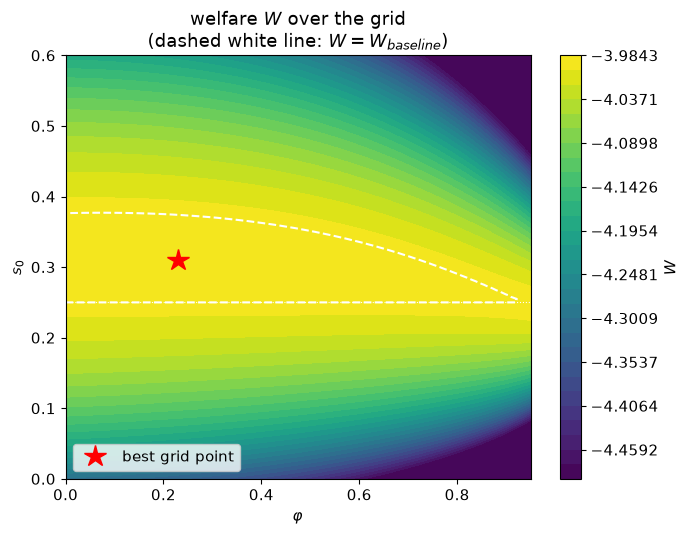

In [13]:
fig,ax = plt.subplots(figsize=(7.5,5.5))

# clip the color scale, otherwise the very bad corner (s0 = 0) dominates
levels = np.linspace(W_baseline-0.5,W_grid_best,30)
cs = ax.contourf(phi_grid,s0_grid,np.clip(W_grid,levels[0],None),levels=levels,cmap='viridis')
ax.contour(phi_grid,s0_grid,W_grid,levels=[W_baseline],colors='white',linewidths=1.5,linestyles='--')

ax.plot(phi_grid_best,s0_grid_best,'r*',ms=16,label='best grid point')
ax.axhline(par.s_bar,color='white',lw=0.8,ls=':')
ax.set_xlabel('$\\varphi$'); ax.set_ylabel('$s_0$')
ax.set_title('welfare $W$ over the grid\n(dashed white line: $W = W_{baseline}$)')
ax.legend(loc='lower left')
fig.colorbar(cs,ax=ax,label='$W$')
ax.grid(False)
plt.show()

### 2. Numerical optimization from the best grid point

In [14]:
obj = lambda x: -model.evaluate(x[0],x[1]) # minimize -W

result = optimize.minimize(obj,x0=[s0_grid_best,phi_grid_best],method='Nelder-Mead',
                           bounds=[(0,0.999),(0,0.999)],
                           options=dict(xatol=1e-10,fatol=1e-12,maxiter=10_000))

s0_opt,phi_opt = result.x
W_opt = -result.fun

print(f'grid:      s0 = {s0_grid_best:.6f}, phi = {phi_grid_best:.6f}, W = {W_grid_best:.8f}')
print(f'optimizer: s0 = {s0_opt:.6f}, phi = {phi_opt:.6f}, W = {W_opt:.8f}')
print(f'gain over the grid: {W_opt-W_grid_best:+.2e}')

grid:      s0 = 0.310000, phi = 0.230000, W = -3.98430600
optimizer: s0 = 0.311497, phi = 0.220770, W = -3.98430029
gain over the grid: +5.71e-06


The optimizer lands essentially on top of the best grid point. It only gains $6\cdot10^{-6}$
in $W$, which is what one should expect: the grid is fine enough ($0.005$ in $s_0$, $0.01$ in
$\varphi$) and $W$ is flat around the maximum. The value of the optimizer here is precision, not
a different answer — but it also confirms that the grid did not miss a better region.

### 3. The best rule against the baseline

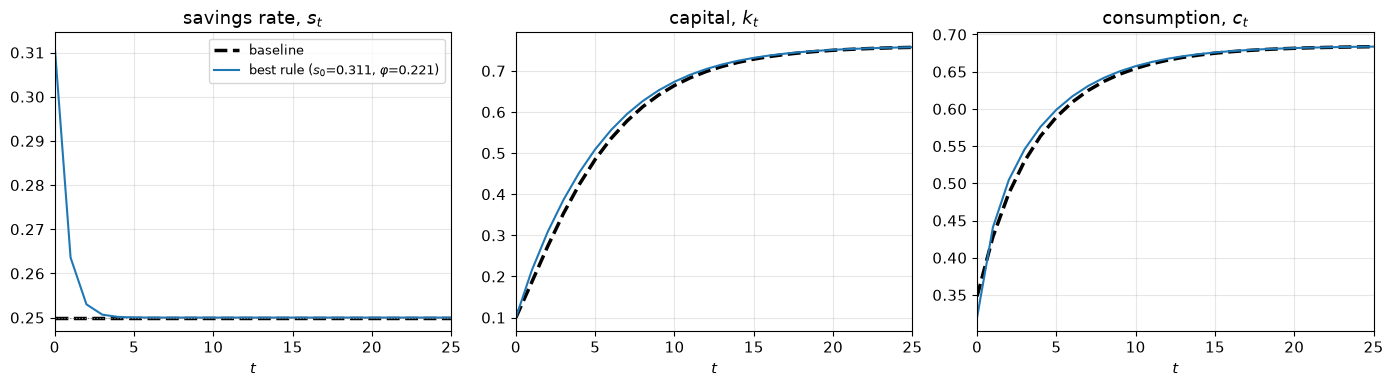

c_0 under the best rule = 0.319575
c_0 under the baseline  = 0.348119
difference              = -0.028544
first period with c_t > c_t^baseline: t = 1


In [15]:
best2 = store(model.simulate(model.s_path(s0_opt,phi_opt)))

fig,axes = plot_paths({'baseline':baseline,f'best rule ($s_0$={s0_opt:.3f}, $\\varphi$={phi_opt:.3f})':best2})
for ax in axes: ax.set_xlim(0,25) # zoom in on the transition, the paths coincide afterwards
axes[0].axhline(par.s_bar,color='grey',lw=0.8,ls=':')
plt.show()

# the first period in which consumption is above the baseline
above = np.where(best2['c'] > baseline['c'])[0]

print(f'c_0 under the best rule = {best2["c"][0]:.6f}')
print(f'c_0 under the baseline  = {baseline["c"][0]:.6f}')
print(f'difference              = {best2["c"][0]-baseline["c"][0]:+.6f}')
print(f'first period with c_t > c_t^baseline: t = {above[0]}')

The optimal rule saves *more* than the baseline at the start ($s_0=0.311$ against $0.25$)
and returns quickly ($\varphi=0.221$, a half-life of well under one period, so $s_t$ is
practically back at $\bar{s}$ by $t=3$).

Consumption is therefore sacrificed in period 0 only — $c_0$ falls by $0.029$ — and is above
the baseline from **$t=1$** onwards. This is the whole trade-off in a nutshell: with $k_0=0.10$
the marginal product of capital is $f'(k_0)=\frac{1}{3}k_0^{-2/3}\approx1.55$, so the gross
return on saving is $1.55+0.70=2.25$, far above $1/\beta=1.2$. Investing an extra unit early
pays off almost immediately. Once capital has grown the return falls, which is why the extra
saving should stop quickly, hence the low $\varphi$.

### Question 5

Now the long-run savings rate is a free parameter too:
$$s_t=s_\infty+(s_0-s_\infty)\varphi^t$$
`s_path` was written with `s_inf` as an optional third argument, so no new code is needed for the
rule itself. Several starting values are used, since a three-dimensional problem is easier to
get stuck in.

In [16]:
obj3 = lambda x: -model.evaluate(x[0],x[1],x[2]) # x = (s0,phi,s_inf)

x0s = [[s0_opt,phi_opt,par.s_bar],[0.60,0.50,0.20],[0.50,0.70,0.15],[0.30,0.30,0.20],[0.60,0.90,0.20]]

best_result = None
for x0 in x0s:
    res = optimize.minimize(obj3,x0=x0,method='Nelder-Mead',bounds=[(0,0.999)]*3,
                            options=dict(xatol=1e-10,fatol=1e-12,maxiter=20_000))
    print(f'  start {np.round(x0,2)} -> W = {-res.fun:.8f}')
    if best_result is None or res.fun < best_result.fun: best_result = res

s0_3,phi_3,sinf_3 = best_result.x
W_3 = -best_result.fun

print()
print(f's0 = {s0_3:.6f}, phi = {phi_3:.6f}, s_inf = {sinf_3:.6f}')
print(f'W  = {W_3:.6f}')
print(f'improvement on Question 4: {W_3-W_opt:+.6f}')

  start [0.31 0.22 0.25] -> W = -3.96696545
  start [0.6 0.5 0.2] -> W = -3.96696545
  start [0.5  0.7  0.15] -> W = -3.96696545
  start [0.3 0.3 0.2] -> W = -3.96696545
  start [0.6 0.9 0.2] -> W = -3.96696545

s0 = 0.313859, phi = 0.670774, s_inf = 0.198944
W  = -3.966965
improvement on Question 4: +0.017335


All starting values converge to the same point, so this looks like the global optimum.

The gain over Question 4 is $+0.0173$, ten times larger than what the two-parameter rule managed
to gain over the baseline ($+0.0100$). Freeing the long-run level matters more than fine-tuning
the transition.

### 2. Capital in the last period

In [17]:
best3 = store(model.simulate(model.s_path(s0_3,phi_3,sinf_3)))

k_ss_new = (sinf_3/par.delta)**(1/(1-par.alpha)) # steady state belonging to s_inf

# the modified golden rule: f'(k)+1-delta = 1/beta
k_mgr = (par.alpha*par.beta/(1-par.beta*(1-par.delta)))**(1/(1-par.alpha))
s_mgr = par.delta*k_mgr**(1-par.alpha)

print(f'k_(T-1) under the best three-parameter rule = {best3["k"][-1]:.6f}')
print(f'k* from Question 1 (s = s_bar = 0.25)       = {k_ss:.6f}')
print(f'steady state belonging to s_inf             = {k_ss_new:.6f}')
print()
print(f'modified golden rule: k = {k_mgr:.6f}, s = {s_mgr:.6f}')

k_(T-1) under the best three-parameter rule = 0.540025
k* from Question 1 (s = s_bar = 0.25)       = 0.760726
steady state belonging to s_inf             = 0.540025

modified golden rule: k = 0.544331, s = 0.200000


**No, they are not the same, and they should not be.**

$k_{T-1}=0.5400$ against $k^*=0.7607$, about 29% less capital.

$\bar{s}=0.25$ was simply imposed; nothing said it was a good savings rate. Once $s_\infty$ is
free the optimizer picks $0.1989$, and capital settles at the steady state belonging to *that*
rate, $(s_\infty/\delta)^{1/(1-\alpha)}=0.5400$, which is exactly $k_{T-1}$.

And $0.199$ is no accident. It is the **modified golden rule**, where the return on capital
equals the rate of time preference,
$$f'(k)+1-\delta=\frac{1}{\beta}\quad\Longrightarrow\quad
k_{mgr}=\left(\frac{\alpha\beta}{1-\beta(1-\delta)}\right)^{\frac{1}{1-\alpha}}=0.5443,
\qquad s_{mgr}=\delta k_{mgr}^{1-\alpha}=0.2000$$
It falls a hair short only because the horizon is finite: there is no reason to leave capital
behind at $T$, and those periods carry weight $\beta^{100}\approx10^{-8}$.

Saving $0.25$ forever is therefore *over*-accumulation: it builds capital whose return,
$f'(k^*)+1-\delta=1.14$, is below $1/\beta=1.2$.

### Question 6

### 1. An alternative functional form

The rule in (6) forces the savings rate towards its long-run level *monotonically and at a single
speed*. A natural generalization is a **sum of two geometric terms**,
$$s_t=s_\infty+A\varphi_1^t+B\varphi_2^t,\qquad \varphi_1,\varphi_2\in[0,1)$$
with parameters $(s_\infty,A,\varphi_1,B,\varphi_2)$.

Both $\varphi_1^t$ and $\varphi_2^t$ vanish, so $s_t\to s_\infty$ and the economy still ends in a
steady state, as the question requires. It nests (6) exactly ($B=0$, $A=s_0-s_\infty$) and so
cannot do worse than Question 5. What it adds is a fast and a slow component that can pull in
opposite directions, allowing a non-monotone path: a sharp burst of saving on top of a gentler
drift towards $s_\infty$.

$s_t$ is clipped to $[0,1]$, which the functional form does not guarantee on its own.

In [18]:
def s_path_mix(x):
    """ the alternative rule s_t = s_inf + A*phi1**t + B*phi2**t """

    s_inf,A,phi1,B,phi2 = x
    t = np.arange(par.T)

    return np.clip(s_inf + A*phi1**t + B*phi2**t,0.0,1.0)

obj6 = lambda x: -model.evaluate_path(s_path_mix(x))

x0s = [[sinf_3,s0_3-sinf_3,phi_3,0.0,0.5],  # the Question 5 solution, B = 0
       [0.20,0.40,0.90,-0.10,0.30],
       [0.20,0.30,0.60,0.10,0.95],
       [0.20,0.20,0.99,0.20,0.50]]

best6 = None
for x0 in x0s:
    res = optimize.minimize(obj6,x0=x0,method='Nelder-Mead',
                            options=dict(xatol=1e-11,fatol=1e-13,maxiter=60_000,maxfev=60_000))
    print(f'  start {np.round(x0,2)} -> W = {-res.fun:.8f}')
    if best6 is None or res.fun < best6.fun: best6 = res

W_6 = -best6.fun
s_6 = s_path_mix(best6.x)
mix6 = store(model.simulate(s_6))

names = ['s_inf','A','phi1','B','phi2']
print()
print(', '.join(f'{n} = {v:.6f}' for n,v in zip(names,best6.x)))
print(f'W = {W_6:.8f}')
print(f's_0 = {s_6[0]:.4f}, s_5 = {s_6[5]:.4f}, s_(T-1) = {s_6[-1]:.4f}, k_(T-1) = {mix6["k"][-1]:.6f}')

  start [0.2  0.11 0.67 0.   0.5 ] -> W = -3.96695135
  start [ 0.2  0.4  0.9 -0.1  0.3] -> W = -3.96695135
  start [0.2  0.3  0.6  0.1  0.95] -> W = -3.96696208
  start [0.2  0.2  0.99 0.2  0.5 ] -> W = -3.96696205

s_inf = 0.199990, A = 0.131840, phi1 = 0.632994, B = -0.018877, phi2 = 0.283977
W = -3.96695135
s_0 = 0.3130, s_5 = 0.2134, s_(T-1) = 0.2000, k_(T-1) = 0.544290


### 2. How much is left to gain? An upper bound

Before comparing, it is worth knowing what the *best possible* savings path achieves. Since any
rule ultimately just produces a vector $(s_0,\dots,s_{T-1})$, $W$ can be maximized over all $T$
savings rates directly, with no functional form imposed at all. That is the full Ramsey problem
solved by brute force, and no parametric rule can beat it.

In [19]:
obj_free = lambda s_vec: -model.evaluate_path(np.clip(s_vec,1e-6,0.999))

res_free = optimize.minimize(obj_free,x0=s_6,method='L-BFGS-B',bounds=[(1e-6,0.999)]*par.T,
                             options=dict(maxiter=200_000,maxfun=200_000,ftol=1e-18,gtol=1e-16))

W_free = -res_free.fun
print(f'W with a completely free savings path = {W_free:.8f}')
print(f'the first ten savings rates: {np.round(res_free.x[:10],4)}')
print(f's_30 = {res_free.x[30]:.4f}, s_60 = {res_free.x[60]:.4f}  (modified golden rule: {s_mgr:.4f})')

W with a completely free savings path = -3.96695135
the first ten savings rates: [0.313  0.2781 0.2513 0.233  0.221  0.2134 0.2085 0.2053 0.2034 0.2021]
s_30 = 0.2000, s_60 = 0.2000  (modified golden rule: 0.2000)


### 3. Comparison

In [20]:
summary = pd.DataFrame([
    {'rule':'baseline, $s_t=\\bar{s}$','parameters':0,'W':W_baseline},
    {'rule':'Q4: $s_t=\\bar{s}+(s_0-\\bar{s})\\varphi^t$','parameters':2,'W':W_opt},
    {'rule':'Q5: $s_t=s_\\infty+(s_0-s_\\infty)\\varphi^t$','parameters':3,'W':W_3},
    {'rule':'Q6: $s_t=s_\\infty+A\\varphi_1^t+B\\varphi_2^t$','parameters':5,'W':W_6},
    {'rule':'upper bound: free $s_t$ each period','parameters':par.T,'W':W_free},
]).set_index('rule')

summary['W - W_baseline'] = summary['W']-W_baseline
summary['gap to the bound'] = W_free-summary['W']

display(summary.style.format({'W':'{:.6f}','W - W_baseline':'{:+.6f}','gap to the bound':'{:.2e}'}))

,parameters,W,W - W_baseline,gap to the bound
rule,,,,
"baseline, $s_t=\bar{s}$",0,-3.994388,+0.000000,2.74e-02
Q4: $s_t=\bar{s}+(s_0-\bar{s})\varphi^t$,2,-3.984300,+0.010087,1.73e-02
Q5: $s_t=s_\infty+(s_0-s_\infty)\varphi^t$,3,-3.966965,+0.027422,1.41e-05
Q6: $s_t=s_\infty+A\varphi_1^t+B\varphi_2^t$,5,-3.966951,+0.027436,6.35e-10
upper bound: free $s_t$ each period,100,-3.966951,+0.027436,0.00e+00


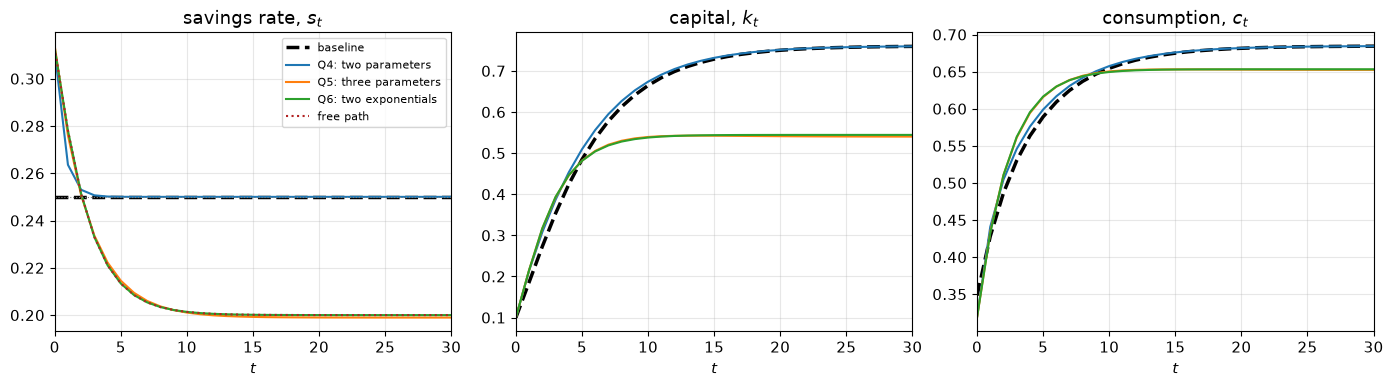

In [21]:
fig,axes = plot_paths({'baseline':baseline,
                       'Q4: two parameters':best2,
                       'Q5: three parameters':best3,
                       'Q6: two exponentials':mix6})
for ax in axes: ax.set_xlim(0,30)
axes[0].plot(np.arange(par.T),res_free.x,':',color='firebrick',lw=1.5,label='free path')
axes[0].axhline(par.s_bar,color='grey',lw=0.8,ls=':')
axes[0].legend(fontsize=8)
plt.show()

### Can it beat them?

**Yes, but only barely.**

The five-parameter rule gains $1.4\cdot10^{-5}$ in $W$ over Question 5, against the $+0.0173$
that Question 5 gained over Question 4. The two paths are indistinguishable.

The last row of the table says why. The free path — the best that *any* rule could do — reaches
$W=-3.966951$, and Question 5 is already within $1.4\cdot10^{-5}$ of it. There was nothing left
to win, and the optimizer duly sets $B\approx-0.019$, a small fast-decaying correction on top of
a path that was already almost right.

This also explains why (6) works so well: the free path falls smoothly from $s_0\approx0.313$ to
the modified golden rule $s_{mgr}=0.20$, with no hump or kink — a shape one exponential
reproduces almost perfectly. The binding constraint in Question 4 was never the shape of the
rule, but the imposed $\bar{s}=0.25$.

## Problem 3

In [22]:
# importing the PortfolioModelClass from the PortfolioModel module
from PortfolioModel import PortfolioModelClass 

### Question 3.1

In this question, we simulate the return on the risky asset using the given parameters, and check that the simulated returns match the model. We then make a figure showing the distribution of returns and how the value of an investment develops over time, for both the risky and the safe asset.

In [23]:
# Creating the portfolio model with the given parameters 

model = PortfolioModelClass()
print(model)

Portfolio model with:
  mu    = 0.0500, sigma = 0.2000, r = 0.0100
  theta_star = 0.5000, Delta = 0.1000, tau = 0.0100
  gamma = 3.0000 (relative risk aversion)
  W0 = 1.00, T = 40, N = 50,000, seed = 2026


In [24]:
# Creating 50 000 random returns from the model

R = model.draw_returns()

# Simulating risky asset returns and checking that the simulated values are consistent with the model

mean_log_R = np.mean(np.log(R))
std_log_R = np.std(np.log(R))
mean_R = np.mean(R)
theoretical_mean_R = np.exp(model.par.mu + 0.5*model.par.sigma**2)

print(f'mean log R = {np.mean(np.log(R)):.4f} vs mu = {model.par.mu:.4f}')
print(f'std log R = {np.std(np.log(R)):.4f} vs sigma = {model.par.sigma:.4f}')
print(f'mean R = {np.mean(R):.4f} vs exp(mu+0.5*sigma^2): {np.exp(model.par.mu+0.5*model.par.sigma**2):.4f}')

# Checking that the simulated values match the theoretical values within a small tolerance 
     # atol=1e-2 --> allows a small tolerance (0.01) between simulated and theoretical values, since the simulation is based on random draws and will never match exactly

assert np.isclose(mean_log_R, model.par.mu, atol=1e-2), 'mean log R does not match mu' 
assert np.isclose(std_log_R, model.par.sigma, atol=1e-2), 'std log R does not match sigma'
assert np.isclose(mean_R, theoretical_mean_R, atol=1e-2), 'mean R does not match theoretical value'

print('\nTest passed: simulated returns are consistent with the model parameters.')

mean log R = 0.0500 vs mu = 0.0500
std log R = 0.2000 vs sigma = 0.2000
mean R = 1.0725 vs exp(mu+0.5*sigma^2): 1.0725

Test passed: simulated returns are consistent with the model parameters.


The simulated returns are consistent with the model parameters. The mean and standard deviation of the log returns are 0.0500 and 0.2000, which match μ = 0.05 and σ = 0.20. The mean gross return is 1.0725, which also matches the theoretical value.

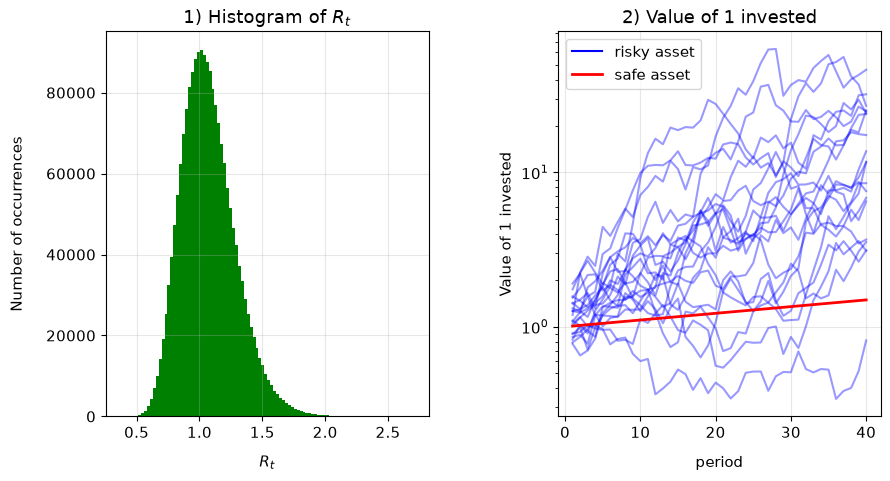

In [25]:
# Creating a figure with two panels 

fig, axes = plt.subplots(1, 2, figsize=(10,5))


# panel 1: histogram of the returns
ax = axes[0]
ax.hist(R.flatten(), bins=100, color='green', alpha=1)
ax.set_title('1) Histogram of $R_t$')
ax.set_xlabel('$R_t$', labelpad = 10)
ax.set_ylabel('Number of occurrences', labelpad = 15)

# panel 2 : value of 1 invested, risky vs safe, for 20 portfolios, log scale
ax = axes[1]

   # Calculate the value of 1 invested in the risky and safe assets
Rf = np.exp(model.par.r)                              # gross return on the safe asset, constant every period
value_risky = np.cumprod(R[:20, :], axis=1)           # shape (20, T)
value_safe = Rf ** np.arange(1, model.par.T + 1)      # shape (T,)

   # Plot the value of 1 invested in the risky and safe assets over time
t = np.arange(1, model.par.T + 1)
ax.plot(t, value_risky.T, color='blue', alpha=0.4)
ax.plot([], [], color='blue', label='risky asset')    # dummy line so the legend shows one entry for all 20 portfolios
ax.plot(t, value_safe, color='red', linewidth=2, label='safe asset')
ax.set_yscale('log')                                  # log scale needed since the risky paths grow at very different rates
ax.set_title('2) Value of 1 invested')
ax.set_xlabel('period', labelpad = 10)
ax.set_ylabel('Value of 1 invested', labelpad = 5)

ax.legend()

fig.subplots_adjust(wspace=0.4)

plt.show()

1) The histogram shows the distribution of simulated returns over 40 periods for 50,000 portfolios. The x-axis represents the returns of the risky asset, while the y-axis represents the frequency of these returns. Most returns are concentrated around the mean, while very low and very high returns are less common. The longer right tail indicates a positive skew, which is characteristic of a lognormal distribution.

2) The figure shows what happens to 1 unit of money invested in the risky asset compared to the safe asset over 40 periods. The blue lines represent the growth of the investment in the risky asset for 20 different portfolios. They all start at around 1 unit of money, but diverge over time due to the randomness of the returns. Some portfolios experience significant growth, while others experience losses. The red line represents the growth of the investment in the safe asset, which grows slowly and predictably due to its constant return. The figure illustrates the potential for higher returns from the risky asset, but also the greater risk and variability compared to the safe asset.





### Question 3.2 

Here we compare the two extreme cases of the trading rule: Delta = 0, where the portfolio is rebalanced to the target share of 50% every period, and Delta = 1, where the portfolio is never traded after the start. In both cases the transaction cost is set to 0, so that the differences are due solely to the trading rule, not to the cost of trading. We use the same drawn returns for both models to ensure a fair comparison. For each rule we report the six numbers required: the number of trades, the average distance to the target, and the mean, median, 10th percentile, and expected utility of terminal wealth

In [26]:
# Trade balanbce, Delta = 0 (always trade)

model_always = PortfolioModelClass(Delta=0.0, tau=0.0)
model_always.simulate(R=R)
summary_always = model_always.summary()

# Trade balance, Delta = 1 (never trade)

model_never = PortfolioModelClass(Delta=1.0, tau=0.0)
model_never.simulate(R=R)
summary_never = model_never.summary()

print('Always trade (Delta=0):')
print(f'  n_trades:  {summary_always.n_trades:.4f}')
print(f'  avg_dist:  {summary_always.avg_dist:.4f}')
print(f'  mean_WT:   {summary_always.mean_WT:.4f}')
print(f'  median_WT: {summary_always.median_WT:.4f}')
print(f'  p10_WT:    {summary_always.p10_WT:.4f}')
print(f'  EU:        {summary_always.EU:.4f}')

print()
print('Never trade (Delta=1):')
print(f'  n_trades:  {summary_never.n_trades:.4f}')
print(f'  avg_dist:  {summary_never.avg_dist:.4f}')
print(f'  mean_WT:   {summary_never.mean_WT:.4f}')
print(f'  median_WT: {summary_never.median_WT:.4f}')
print(f'  p10_WT:    {summary_never.p10_WT:.4f}')
print(f'  EU:        {summary_never.EU:.4f}')

Always trade (Delta=0):
  n_trades:  39.0000
  avg_dist:  0.0394
  mean_WT:   5.0436
  median_WT: 4.0815
  p10_WT:    1.7937
  EU:        -0.0678

Never trade (Delta=1):
  n_trades:  0.0000
  avg_dist:  0.1911
  mean_WT:   8.9756
  median_WT: 4.4478
  p10_WT:    1.4855
  EU:        -0.0767


Never trade gives higher wealth on average, but it also involves more risk. Always trade keeps the portfolio closer to the target and performs better in worse outcomes. It also gives higher expected utility, which means that the risk-averse investor prefers the always-trade strategy.

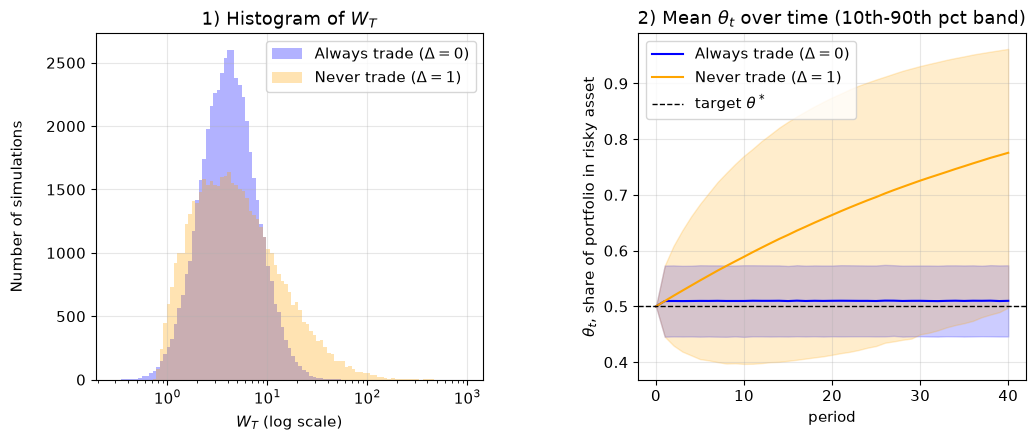

In [27]:
# Creating a figure with two panels to compare the two trading rules

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# panel 1:histogram of wealth for the two rules, log scale on x-axis
ax = axes[0]
wealth_always = model_always.sim.W[:, -1] 
wealth_never = model_never.sim.W[:, -1]

# Determine the min and max wealth across both strategies to set the bins for the histogram
wealth_min = min(wealth_always.min(), wealth_never.min())
wealth_max = max(wealth_always.max(), wealth_never.max())
bins = np.logspace(np.log10(wealth_min), np.log10(wealth_max), 100)    # log-spaced bins are used because terminal wealth is right-skewed with a long tail, which would otherwise be hard to see on a linear scale

# Plot the histograms for both rules with transparency and labels
ax.hist(wealth_always, bins= bins, alpha=0.3, label='Always trade ($\\Delta=0$)', color='blue')
ax.hist(wealth_never, bins= bins, alpha=0.3, label='Never trade ($\\Delta=1$)', color='orange')
ax.set_xscale('log')

ax.set_title('1) Histogram of $W_T$')
ax.set_xlabel('$W_T$ (log scale)', labelpad = 5)
ax.set_ylabel('Number of simulations', labelpad = 15)
ax.legend()

# panel 2: mean theta_t over time, with 10th-90th percentile band
ax = axes[1]
t = np.arange(model.par.T + 1)

# Compute mean and percentiles of theta_t for both trading rules
theta_always = model_always.sim.theta
theta_never = model_never.sim.theta

mean_always = np.mean(theta_always, axis=0)
p10_always = np.percentile(theta_always, 10, axis=0)
p90_always = np.percentile(theta_always, 90, axis=0)

mean_never = np.mean(theta_never, axis=0)
p10_never = np.percentile(theta_never, 10, axis=0)
p90_never = np.percentile(theta_never, 90, axis=0)

# Plot the mean and 10th-90th percentile bands for both trading rules
ax.plot(t, mean_always, color='blue', label='Always trade ($\\Delta=0$)')
ax.fill_between(t, p10_always, p90_always, color='blue', alpha=0.2)   # fill_between shows the range where about 80% of the simulated portfolios lie at each period

ax.plot(t, mean_never, color='orange', label='Never trade ($\\Delta=1$)')
ax.fill_between(t, p10_never, p90_never, color='orange', alpha=0.2)

ax.axhline(model.par.theta_star, color='black', linestyle='--', linewidth=1, label='target $\\theta^*$')
ax.set_title('2) Mean $\\theta_t$ over time (10th-90th pct band)')
ax.set_xlabel('period')
ax.set_ylabel('$\\theta_t$, share of portfolio in risky asset')
ax.legend()


fig.subplots_adjust(wspace=0.4)

plt.show()

1) The first panel shows the distribution of terminal wealth for the two strategies after 40 periods. The always-trade strategy has a higher and narrower peak, meaning that many of the simulated portfolios end with similar levels of wealth. This is because the portfolio is regularly rebalanced back towards the target of 50% in the risky asset and 50% in the safe asset, which limits how much the risky share can change over time.
The never-trade strategy has a wider distribution, meaning that there is more variation in terminal wealth across the simulated portfolios. Without rebalancing, the risky share can increase or decrease depending on how the risky asset performs. In simulations where the risky asset performs very well, it can become a large part of the portfolio and lead to very high terminal wealth. This creates the long right tail in the distribution and helps explain why the never-trade strategy has a higher average terminal wealth (8.98 compared to 5.04). However, the wider distribution also shows that the outcomes are less stable. This is also reflected in the 10th percentile of terminal wealth, which is higher for the always-trade strategy (1.79) than for the never-trade strategy (1.49), confirming that always-trade performs better in the worst-case scenarios.

2) The second panel shows the share of the portfolio invested in the risky asset over time for the two strategies. The always-trade strategy keeps the risky share close to the target of 50% because the portfolio is regularly rebalanced. In contrast, with the never-trade strategy, the risky share is allowed to change freely. Since the risky asset has a higher return on average than the safe asset, its value can grow faster and therefore make up a larger share of the portfolio over time. Because there is no rebalancing, the portfolio is not adjusted back towards the 50% target.
The shaded areas show the range between the 10th and 90th percentiles of the risky share across the simulated portfolios. This means that about 80% of the simulated risky shares are between the lower and upper boundaries of the shaded area at each period. The orange area becomes much wider over time, showing that the risky share varies considerably across the never-trade portfolios. Some portfolios end up with a very high risky share, while others have a much lower risky share. The always-trade strategy has a much narrower area because regular rebalancing keeps the portfolios closer to the 50% target.

### Question 3.3

In this question, we set the transaction cost to 0.01 and test nine different values of Delta, from always trading (Delta = 0) to never trading (Delta = 1). For each value, we report the six required numbers in a table, and plot how the number of trades, the distance to target, and expected utility depend on Delta. We then identify which Delta gives the best outcome.

In [28]:
# Report the six numbers for nine values of Delta, with tau = 0.01

deltas = [0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1]
rows = []

# Creating the loop to simulate the portfolio model for each value of Delta and store the results in a list of dictionaries

for delta in deltas:
    m = PortfolioModelClass(Delta=delta, tau=0.01)
    m.simulate(R=R)
    s = m.summary()
    rows.append({
        'Delta': delta,
        'n_trades': s.n_trades,
        'avg_dist': s.avg_dist,
        'mean_WT': s.mean_WT,
        'median_WT': s.median_WT,
        'p10_WT': s.p10_WT,
        'EU': s.EU
    })

table = pd.DataFrame(rows).set_index('Delta')
table.round(4)


,n_trades,avg_dist,mean_WT,median_WT,p10_WT,EU
Delta,,,,,,
0.000,39.0000,0.0394,4.9624,4.0184,1.7683,-0.0699
0.025,24.5235,0.0400,4.9746,4.0184,1.7692,-0.0697
0.050,14.3334,0.0429,5.0155,4.0358,1.7674,-0.0695
0.075,8.7905,0.0480,5.0739,4.0476,1.7655,-0.0693
0.100,5.8603,0.0541,5.1459,4.0606,1.7594,-0.0695
0.150,3.1519,0.0680,5.3285,4.1042,1.7353,-0.0700
0.200,1.9503,0.0835,5.5596,4.1863,1.6792,-0.0709
0.300,0.9055,0.1180,6.1957,4.3414,1.5361,-0.0734
1.000,0.0000,0.1911,8.9756,4.4478,1.4855,-0.0767


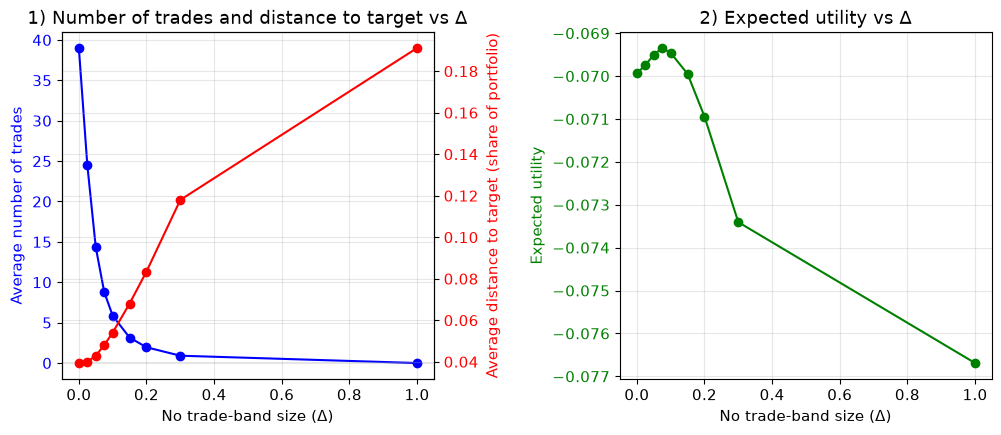

In [29]:
# Creating a figure with 2 panels 

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# panel 1:  number of trades and average distance to target against Delta with two y-axes because of different scales

ax1 = axes[0]

ax1.plot(table.index, table['n_trades'], color='blue', marker='o', label='n_trades')
ax1.set_xlabel('No trade-band size ($\\Delta$)')
ax1.set_ylabel('Average number of trades', color='blue', labelpad = 5)
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()       # Creating a second y-axis for the average distance to target
ax2.plot(table.index, table['avg_dist'], color='red', marker='o', label='avg_dist')
ax2.set_ylabel('Average distance to target (share of portfolio)', color='red', labelpad = 5)
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_title('1) Number of trades and distance to target vs $\\Delta$')

# panel 2: expected utility against Delta
ax = axes[1]
ax.plot(table.index, table['EU'], color='green', marker='o')
ax.set_xlabel('No trade-band size ($\\Delta$)')
ax.set_ylabel('Expected utility', color = 'green', labelpad = 5)
ax.tick_params(axis='y', labelcolor='green')
ax.set_title('2) Expected utility vs $\\Delta$')


fig.subplots_adjust(wspace=0.5)

plt.show()


1) The first panel shows the relationship between the size of the no-trade band and how often the investor trades, as well as how far the portfolio moves from the target of 50% in the risky asset. The blue line shows the average number of trades, while the red line shows the average distance from the target. As expected, the number of trades decreases as the no-trade band becomes larger, because the investor allows the portfolio to move further away from the target before trading. At the same time, the average distance from the target increases as the no-trade band becomes larger, meaning that the portfolio, on average, moves further away from the target of 50% in the risky asset.

2) The second panel shows how the size of the no-trade band affects expected utility. Expected utility first increases and reaches its highest value at Delta = 0.075. After this point, expected utility starts to decrease. This suggests that a small no-trade band is better than always trading or never trading. It gives a good balance between reducing trading costs and keeping the portfolio close to the target. The improvement in expected utility is small compared to always trading (Delta = 0), from -0.0699 to -0.0693 with a gain of about 0.0006. The improvement compared to never trading (Delta = 1) is much larger, from -0.0767 to -0.0693, with a gain of about 0.0074.


### What happens if Delta grows? 

As Delta grows, the investor trades less often, and the risky share drifts further from the target. This increases risk, but also increases the average return.

Going from Delta = 0 to the best outcome of Delta when Delta is equal to 0.075, the number of trades drops a lot (39 to about 8.8), and the average distance from the target grows a bit (0.039 to 0.048). But expected utility barely changes (-0.0699 to -0.0693), and the other wealth numbers (mean, median, 10th percentile) also stay almost the same. This is why Delta = 0.075 is the better pick, it gives almost the same expected utility as always trading, but requires far less trades which means lower transaction costs for almost no loss in performance. 

Always trading (Delta = 0) is not wrong, but can be wasteful, since it pays transaction costs for something that doesn't significantly improves the outcome. Never trading (Delta = 1) looks attractive if you only look at average wealth, but is clearly the worst choice once risk is taken into account, since a risk-averse investor cares about the whole distribution of outcomes, not just the average. 

To answer the last question in 3.3.4: No, if we were able to choose which Delta to use (that is how often to actively rebalance the portfolio), we would not go with the rule that gives the highest mean terminal wealth. The mean is highest at Delta = 1, but we know this comes with the highest risk, and does not necessarily mean the highest utility. Instead, we would pick Delta = 0.075, since we know it gives the highest expected utility of all the rules tested, while requiring far fewer trades and therefore lower transaction costs, than Delta = 0.
